<a href="https://colab.research.google.com/github/Aditi-dev07/Cisco_DataScience_Projects/blob/main/Data%20Modeling/Animal%20sleep/animal-sleep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Animal Sleep

Some animals, such as elephants, sleep only 3-4 hours a night, while others, like bats, can sleep up to 20 hours.

Is there a relationship between sleep duration and body mass? Is a species' diet correlated with sleep time?

The file `animal-sleep.csv` provides data on the average sleep duration of 77 animal species, along with their average body mass in kilograms.

In [4]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'animal-sleep.csv' and 'linear_model.py'.

from google.colab import files
uploaded = files.upload()

Saving animal-sleep.csv to animal-sleep (1).csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('animal-sleep.csv')
df.head()

,animal,diet,sleep,mass
0,african elephant,herbivore,3.3,6654.000
1,african giant pouched rat,omnivore,8.3,1.000
2,african striped mouse,herbivore,8.7,0.044
3,arctic fox,carnivore,12.5,3.380
4,arctic ground squirrel,omnivore,16.6,0.920


Text(0, 0.5, 'hours of sleep per day')

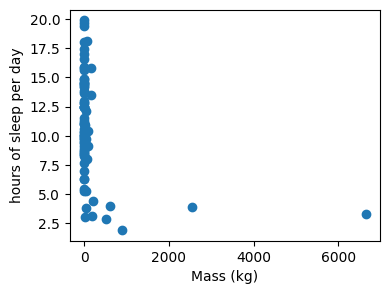

In [2]:
plt.figure(figsize=(4, 3))
plt.scatter(df['mass'], df['sleep'])
plt.xlabel('Mass (kg)')
plt.ylabel('hours of sleep per day')

We see that the mass data exhibits a strong right skew with a long tail. A log transformation can convert an exponential relationship into a linear one, making it easier to model with linear regression.

In [3]:
import math
df['log10_mass'] = df['mass'].apply(math.log10)  # apply the function to each element
df.head()

,animal,diet,sleep,mass,log10_mass
0,african elephant,herbivore,3.3,6654.000,3.823083
1,african giant pouched rat,omnivore,8.3,1.000,0.000000
2,african striped mouse,herbivore,8.7,0.044,-1.356547
3,arctic fox,carnivore,12.5,3.380,0.528917
4,arctic ground squirrel,omnivore,16.6,0.920,-0.036212


Below is code for plotting the data using the log scale.

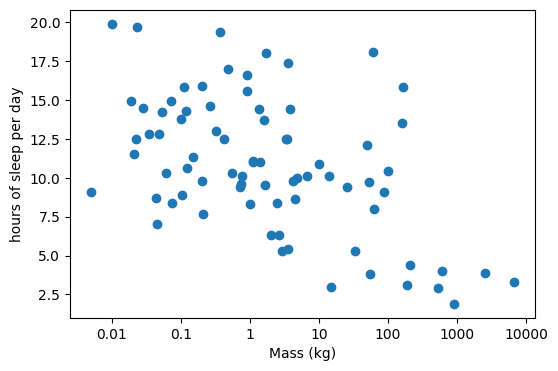

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(df['log10_mass'], df['sleep'])
plt.xlabel('Mass (kg)')
plt.ylabel('hours of sleep per day')
xticks = [-2, -1, 0, 1, 2, 3, 4]
xtick_labels = [0.01, 0.1, 1, 10, 100, 1000, 10000]
plt.xticks(xticks, xtick_labels)
plt.show()

### Project Ideas

- Model the relationship between `log10_mass` and hours of `sleep`.

- Create three separate linear models for each `diet` category: carnivores, omnivores, and herbivores.

- Visualize the data and their best-fit lines on a single plot with distinct colors and symbols for each `diet` category, or use separate plots if more suitable.

- Explore and propose mechanisms that could explain the results, potentially involving additional research.

# Task

#1.Model the relationship between log10_mass and hours of sleep.

In [5]:
linear = LinearModel()
x = df['log10_mass']
y = df['sleep']
linear.fit(x, y)
print("Linear model fitted successfully.")

Linear model fitted successfully.


In [6]:
linear.print_model_info()

LinearModel():
Slope: -1.614969173377659
Intercept: 11.217396810788516
R-squared: 0.26432361005128435


#2.Create three separate linear models for each diet category: carnivores, omnivores, and herbivores.

#Carnivor

In [7]:
carnivor = df[df['diet'] == 'carnivore'].copy()
carnivor_x = carnivor['log10_mass']
carnivor_y = carnivor['sleep']
carnivore_linear_model = LinearModel()
carnivore_linear_model.fit(carnivor_x, carnivor_y)
print("Carnivore Linear Model fitted successfully.")
carnivore_linear_model.print_model_info()

Carnivore Linear Model fitted successfully.
LinearModel():
Slope: -0.14090226025203156
Intercept: 12.99704850696372
R-squared: 0.003186503413273978


#Omnivor

In [8]:
omnivor = df[df['diet'] == 'omnivore'].copy()
omnivor_x = omnivor['log10_mass']
omnivor_y = omnivor['sleep']
omnivore_linear_model = LinearModel()
omnivore_linear_model.fit(omnivor_x, omnivor_y)
print("Omnivore Linear Model fitted successfully.")
omnivore_linear_model.print_model_info()

Omnivore Linear Model fitted successfully.
LinearModel():
Slope: -1.0841960083999436
Intercept: 11.662140158348944
R-squared: 0.10944681716489979


#Herbivor

In [10]:
herbivor = df[df['diet'] == 'herbivore'].copy()
herbivor_x = herbivor['log10_mass']
herbivor_y = herbivor['sleep']
herbivore_linear_model = LinearModel()
herbivore_linear_model.fit(herbivor_x, herbivor_y)
print("Herbivore Linear Model fitted successfully.")
herbivore_linear_model.print_model_info()

Herbivore Linear Model fitted successfully.
LinearModel():
Slope: -2.2408355966298785
Intercept: 9.596484459635365
R-squared: 0.6255104280867234


#3.Visualize the data and their best-fit lines on a single plot with distinct colors and symbols for each diet category, or use separate plots if more suitable.

In [16]:
def clear_axes():
  ax = plt.gca()
  ax.spines[['top','bottom','left','right']].set_visible(False)
  ax.grid(axis='x', color='black', alpha=0.5)
  ax.tick_params(axis='both', length=0)

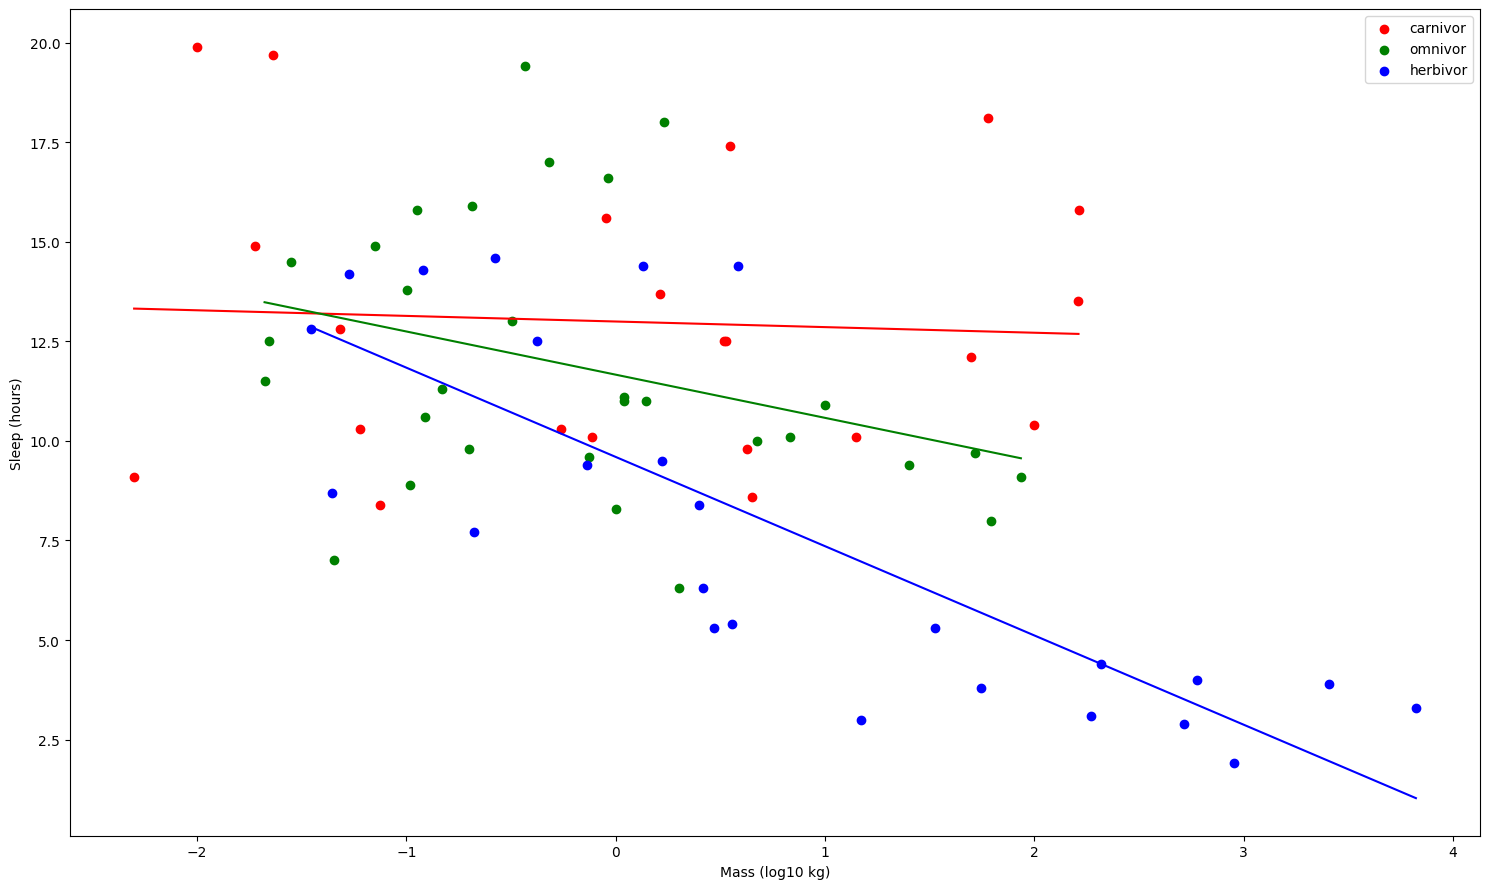

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 9))


plt.scatter(x=carnivor_x, y=carnivor_y, color='red', label='carnivor')
carnivore_linear_model.plot_model(carnivor_x.min(), carnivor_x.max(), color='red')
plt.xlabel('Mass (log10 kg)')
plt.ylabel('Sleep (hours)')



plt.scatter(x=omnivor_x, y=omnivor_y, color='green', label = 'omnivor')
omnivore_linear_model.plot_model(omnivor_x.min(), omnivor_x.max(), color='green')
plt.xlabel('Mass (log10 kg)')
plt.ylabel('Sleep (hours)')



plt.scatter(x=herbivor_x, y=herbivor_y, color='blue', label = 'herbivor')
herbivore_linear_model.plot_model(herbivor_x.min(), herbivor_x.max(), color='blue')
plt.xlabel('Mass (log10 kg)')
plt.ylabel('Sleep (hours)')


plt.legend()
plt.tight_layout()
plt.show()

#4.Explore and propose mechanisms that could explain the results, potentially involving additional research.

### Explanation of Results and Proposed Mechanisms

**Overall Model (`log10_mass` vs. `sleep`):**

The initial model showed a negative correlation between `log10_mass` and hours of sleep, with larger animals tending to sleep less. The R-squared value was 0.264, indicating that body mass explains about 26.4% of the variability in sleep duration. This suggests that while there is a general trend, other significant factors are at play.

**Diet-Specific Models:**

1.  **Carnivores:**
    *   **Slope:** -0.141
    *   **Intercept:** 12.997
    *   **R-squared:** 0.003
    The model for carnivores shows a very weak negative relationship (almost flat line) between `log10_mass` and sleep duration, with an extremely low R-squared. This implies that for carnivores, body mass is a poor predictor of sleep duration.
    
    **Proposed Mechanism:** Carnivores, being predators, may face less constant predation pressure during sleep compared to herbivores. Their sleep patterns might be more influenced by hunting success, food availability, or social structures rather than solely body mass. Smaller carnivores might also be efficient hunters and not need excessively long sleep periods related to their size, as their prey is energy-dense.

2.  **Omnivores:**
    *   **Slope:** -1.084
    *   **Intercept:** 11.662
    *   **R-squared:** 0.109
    Omnivores show a moderate negative relationship, with `log10_mass` explaining about 10.9% of sleep variability. This is a stronger relationship than carnivores but weaker than herbivores.
    
    **Proposed Mechanism:** Omnivores have a mixed diet, leading to varied energy acquisition and potential risks. Their sleep patterns might be a blend of the factors affecting both carnivores and herbivores, hence a moderate correlation with body mass. Factors like opportunistic foraging and adaptable defense mechanisms might lead to a less pronounced mass-sleep relationship compared to specialized herbivores.

3.  **Herbivores:**
    *   **Slope:** -2.241
    *   **Intercept:** 9.596
    *   **R-squared:** 0.625
    The model for herbivores exhibits a strong negative correlation, with `log10_mass` explaining a substantial 62.5% of the variance in sleep duration. Larger herbivores tend to sleep significantly less.
    
    **Proposed Mechanism:** Herbivores often spend much of their day foraging for low-energy plant matter. Smaller herbivores are generally more vulnerable to predators and may need to be more vigilant, leading to shorter or fragmented sleep. Larger herbivores, due to their size, might face fewer predators (e.g., elephants), allowing them to sleep for longer or more deeply. Additionally, their digestive processes (e.g., rumination in some species) can be lengthy and might limit uninterrupted sleep time, especially for smaller species that need to eat more frequently relative to their body mass.

**Overall Insights and Further Research:**

*   **Predation Risk:** A major driver for differences in sleep duration across diet groups seems to be predation risk. Animals higher up the food chain (carnivores) or those large enough to deter predators (large herbivores) might afford more sleep.
*   **Metabolic Rate & Diet Quality:** Smaller animals generally have higher metabolic rates and may require more energy intake. The energy density of their diet (meat vs. plants) could influence how much time they can allocate to sleep versus foraging/hunting.
*   **Brain Size and Cognitive Demands:** Some research suggests a link between brain size (and thus cognitive demands) and sleep duration, especially REM sleep. This dataset does not include such factors, but it could be an area for further investigation.
*   **Environmental Factors:** Habitat, climate, and social behavior are other factors not considered here that could significantly influence sleep patterns.

To further explore these mechanisms, additional research could involve:
*   Including variables related to predation risk (e.g., presence of major predators, anti-predator defenses).
*   Incorporating data on metabolic rates, digestive complexity, and diet energy density.
*   Analyzing sleep architecture (e.g., proportion of REM vs. NREM sleep) to understand qualitative differences in sleep.